In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


2024-05-13 13:30:38.372129: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-13 13:30:38.372244: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-13 13:30:38.488575: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
(X_train, y_train) , (X_test, y_test) =  keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
X_train[0].shape

(28, 28)

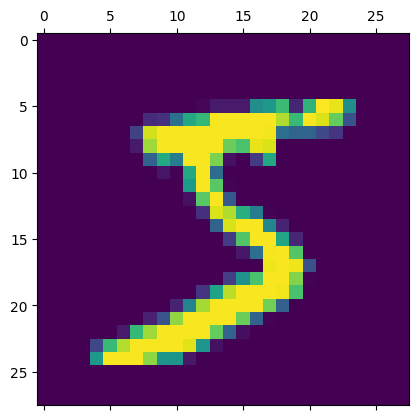

In [6]:
plt.matshow(X_train[0])

In [7]:
y_train[0]

5

In [8]:
# Reshape the data for EDA (flatten the 28x28 images)
x_train = X_train.reshape(X_train.shape[0], -1)
x_test = X_test.reshape(X_test.shape[0], -1)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [10]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


In [11]:
import pandas as pd

# Create a DataFrame for EDA
data = pd.DataFrame(data=x_train, columns=[f'Pixel_{i}' for i in range(x_train.shape[1])])
data['Label'] = y_train

In [12]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(data, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

/opt/conda/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



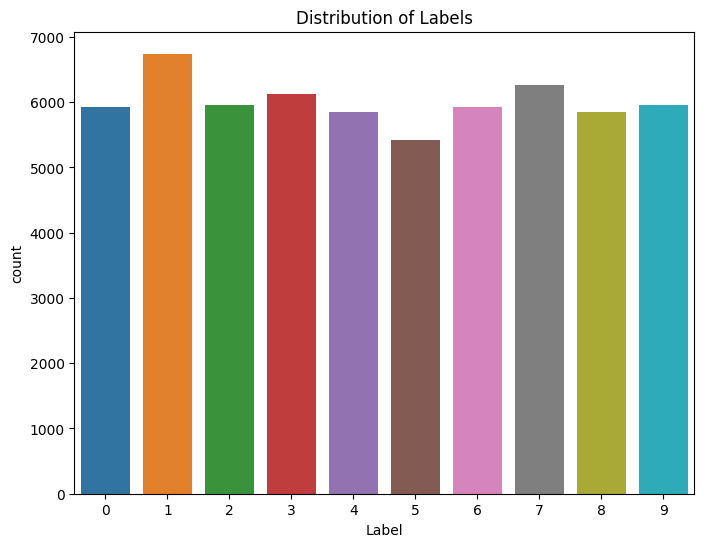

In [13]:
import seaborn as sns
# Distribution of Labels
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Label')
plt.title('Distribution of Labels')
plt.show()

In [14]:
X_train = X_train / 255
X_test = X_test / 255

In [15]:
#preprocess the MNIST dataset
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_train = np.expand_dims(X_train, axis=-1)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import regularizers

# Define dropout_rate and l2_strength
dropout_rate = 0.5
l2_strength = 0.001

def create_and_train_model(num_fc_layers, dropout_rate=0.5, l2_strength=0.001):
    model = keras.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())

    for _ in range(num_fc_layers):
        model.add(keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_strength)))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    model.add(keras.layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
    history = model.fit(X_train.reshape(-1, 28, 28, 1), y_train,
                        epochs=5,
                        validation_data=(X_val.reshape(-1, 28, 28, 1), y_val),
                        callbacks=[early_stopping, checkpoint],
                        verbose=1)

    return model, history




In [17]:
num_fc_layers_list = [0,1]

# Train models with different configurations
models = []
histories = []

for num_fc_layers in num_fc_layers_list:
    model, history = create_and_train_model(num_fc_layers, dropout_rate=dropout_rate, l2_strength=l2_strength)
    models.append(model)
    histories.append(history)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
  81/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1510 - loss: 2.2895

I0000 00:00:1715607063.510010     108 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1715607063.525950     108 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7201 - loss: 0.8533

W0000 00:00:1715607067.259105     108 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7212 - loss: 0.8502 - val_accuracy: 0.9596 - val_loss: 0.1400
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9616 - loss: 0.1271 - val_accuracy: 0.9689 - val_loss: 0.1055
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9739 - loss: 0.0841 - val_accuracy: 0.9777 - val_loss: 0.0717
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9798 - loss: 0.0650 - val_accuracy: 0.9828 - val_loss: 0.0577
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9835 - loss: 0.0517 - val_accuracy: 0.9807 - val_loss: 0.0585
Epoch 1/5
  62/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3857 - loss: 2.1651

W0000 00:00:1715607088.418626     111 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8259 - loss: 0.6525

W0000 00:00:1715607092.844799     110 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8264 - loss: 0.6509 - val_accuracy: 0.9682 - val_loss: 0.1527
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9662 - loss: 0.1569 - val_accuracy: 0.9642 - val_loss: 0.1534
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9735 - loss: 0.1245 - val_accuracy: 0.9790 - val_loss: 0.0981
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9768 - loss: 0.1077 - val_accuracy: 0.9839 - val_loss: 0.0870
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9801 - loss: 0.0989 - val_accuracy: 0.9856 - val_loss: 0.0781


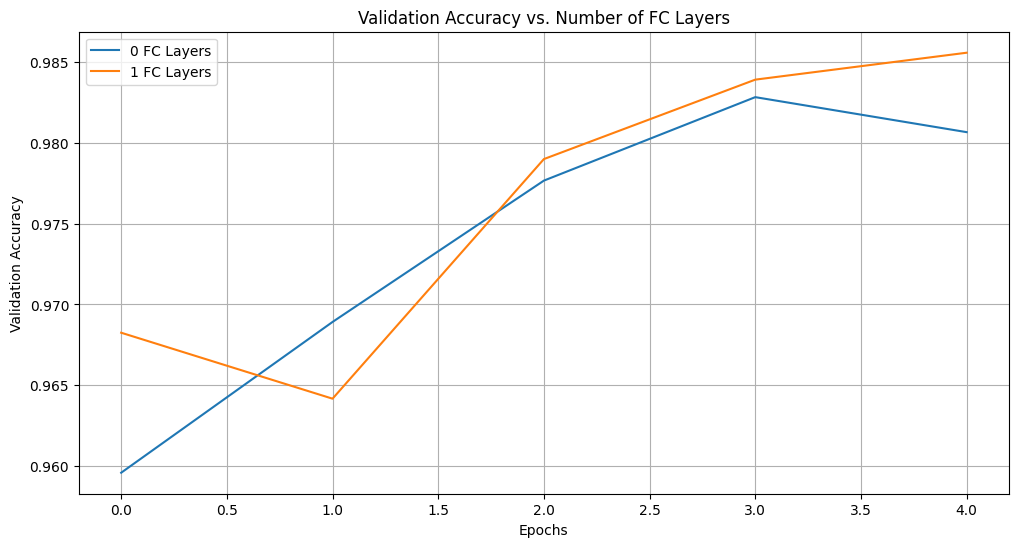

In [18]:
plt.figure(figsize=(12, 6))

for i, num_fc_layers in enumerate(num_fc_layers_list):
    plt.plot(histories[i].history['val_accuracy'], label=f'{num_fc_layers} FC Layers')

plt.title('Validation Accuracy vs. Number of FC Layers')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

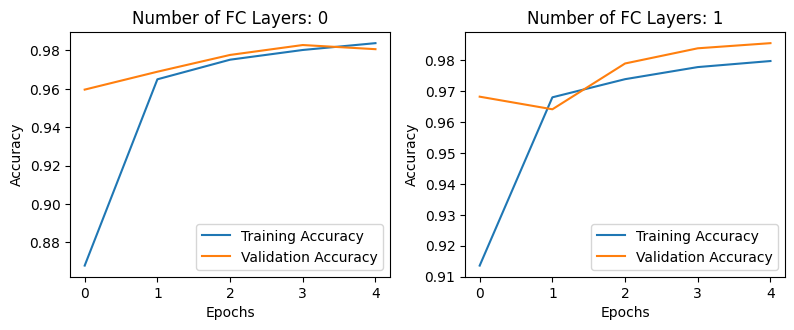

In [19]:
plt.figure(figsize=(12, 6))

for i, num_fc_layers in enumerate(num_fc_layers_list[:5]):
    plt.subplot(2, 3, i+1)
    plt.plot(histories[i].history['accuracy'], label='Training Accuracy')
    plt.plot(histories[i].history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Number of FC Layers: {num_fc_layers}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()

In [20]:
#Analyze the size of each model in terms of the number of parameters.
model_sizes = [model.count_params() for model in models]

for i, num_fc_layers in enumerate(num_fc_layers_list):
    print(f'Model with {num_fc_layers} FC Layers - Number of Parameters: {model_sizes[i]}')

Model with 0 FC Layers - Number of Parameters: 61514
Model with 1 FC Layers - Number of Parameters: 131402


In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [22]:
# Define the data for the correlation matrix
num_fc_layers = len(num_fc_layers_list)
correlation_data = np.zeros((num_fc_layers, num_fc_layers, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


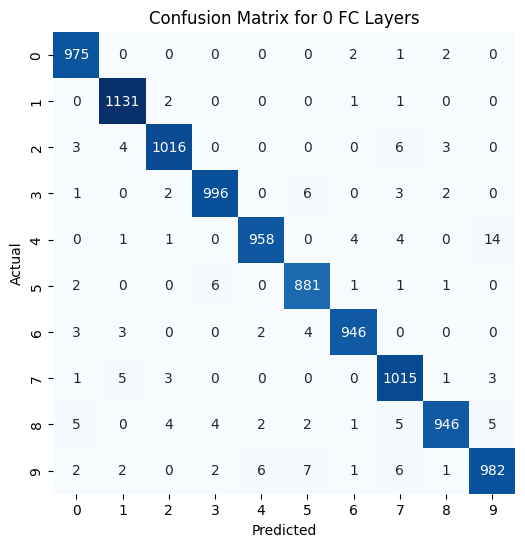

118/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

W0000 00:00:1715607114.379174     109 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


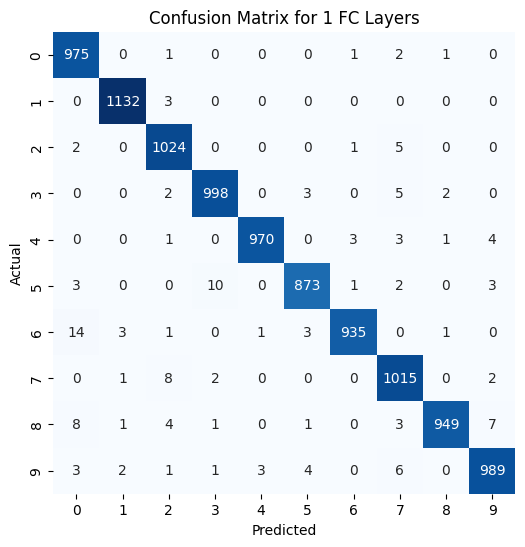

In [23]:
# Create confusion matrices for each model
for i, num_fc_layers in enumerate(num_fc_layers_list):
    y_pred = np.argmax(models[i].predict(X_test.reshape(-1, 28, 28, 1)), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {num_fc_layers} FC Layers')
    plt.show()


In [24]:
# Populate the correlation matrix with data
for i in range(num_fc_layers):
    for j in range(num_fc_layers):
        correlation_data[i, j, 0] = histories[i].history['accuracy'][-1]  # Training Accuracy
        correlation_data[i, j, 1] = histories[i].history['val_accuracy'][-1]  # Validation Accuracy
        correlation_data[i, j, 2] = histories[i].history['loss'][-1]  # Training Loss
        correlation_data[i, j, 3] = histories[i].history['val_loss'][-1]  # Validation Loss


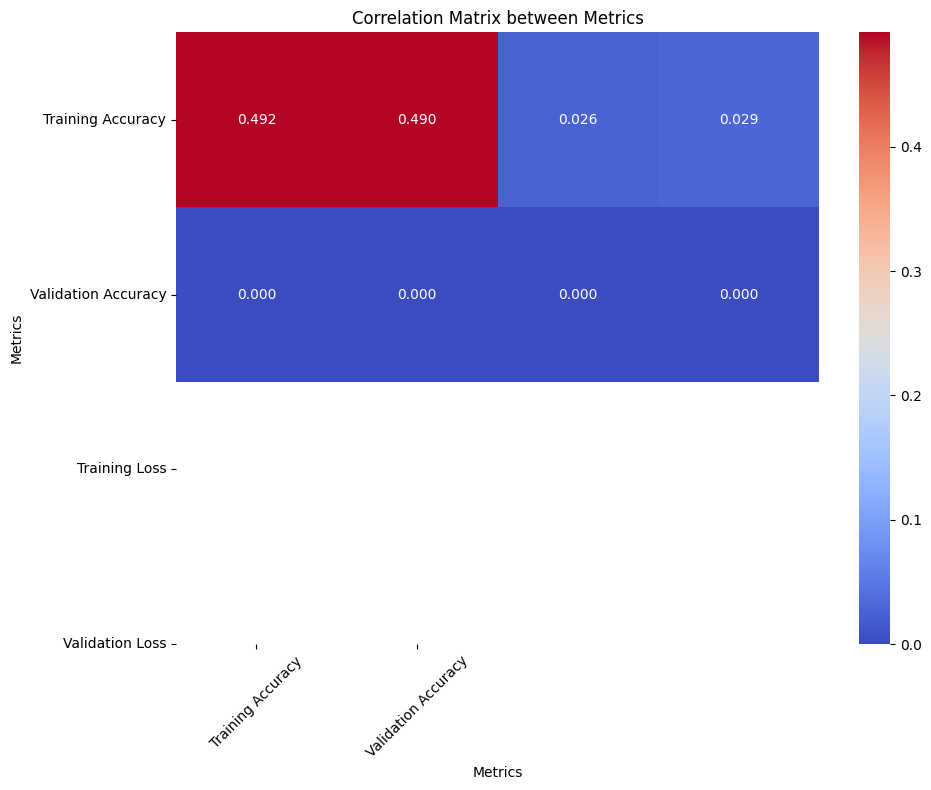

In [32]:
import seaborn as sns

# Create a single heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data.mean(axis=0), annot=True, fmt=".3f", cmap="coolwarm", cbar=True, 
            xticklabels=['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss'],
            yticklabels=['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss'])
plt.title('Correlation Matrix between Metrics')
plt.xlabel('Metrics')
plt.ylabel('Metrics')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
# Model Performance:
for i, model in enumerate(models):
    test_loss, test_accuracy = model.evaluate(X_test.reshape(-1, 28, 28, 1), y_test, verbose=0)
    print(f'Model with {num_fc_layers_list[i]} FC Layers - Test Accuracy: {test_accuracy:.4f}')


W0000 00:00:1715607116.730544     110 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


Model with 0 FC Layers - Test Accuracy: 0.9846


W0000 00:00:1715607118.242496     108 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


Model with 1 FC Layers - Test Accuracy: 0.9860


In [27]:
model.save("mnist_model.h5")